# Imports

In [1]:
import copy
import os
import pickle
import sqlite3
import tempfile
import time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import torch.nn.functional as F
import torch.nn.utils.prune as prune
import torch.optim as optim
from IPython.display import clear_output
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Model Testing

## Testing Guide
1. Click on the Setup button
2. Wait for the Setup button to stop loading.
3. Click on the button to run the Model Testing cell
4. Type in the beatmap_id you'd like to test and hit enter

In [ ]:
def parse_osu_file(file_path, max_slider_length = 1, max_time_diff = 1, print_info = False):
    """
    This one is probably fine, shouldn't require any ML/DL libs...

    :param file_path:
    :param max_slider_length:
    :param max_time_diff:
    :param print_info:
    :return:
    """
    data = {
        'beatmap_id': None,
        'hp_drain': None,
        'circle_size': None,
        'od': None,
        'ar': None,
        'slider_multiplier': None,
        'slider_tick': None,
        'hit_objects': [],
        'label': None,
    }

    parent_folder = os.path.dirname(file_path)
    data['label'] = os.path.basename(parent_folder)

    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
        section = None

        for line in lines:
            line = line.strip()

            if not line:
                continue

            if line.startswith('[') and line.endswith(']'):
                section = line[1:-1]
                continue

            if section == 'Metadata':
                key, value = line.split(':', maxsplit=1)
                if key == 'Title' and print_info:
                    print("Title: " + value, end = ' ')
                if key == 'Artist' and print_info:
                    print("by " + value)
                if key == 'Creator' and print_info:
                    print("Mapper: " + value)
                if key == 'Version' and print_info:
                    print("Diffuculty: " + value)
                if key == 'BeatmapID':
                    data['beatmap_id'] = int(value)
                    print("ID: " + value)
                    print("----------------------------------------------------")
                    if data['beatmap_id'] is None:
                        return None
            elif section == 'Difficulty':
                key, value = line.split(':', maxsplit=1)
                value = float(value)
                if key == 'HPDrainRate':
                    data['hp_drain'] = value
                elif key == 'CircleSize':
                    data['circle_size'] = value
                elif key == 'OverallDifficulty':
                    data['od'] = value
                elif key == 'ApproachRate':
                    data['ar'] = value
                elif key == 'SliderMultiplier':
                    data['slider_multiplier'] = value
                elif key == 'SliderTickRate':
                    data['slider_tick'] = value
            elif section == 'HitObjects':  # Move this line one level back
                    obj_data = line.split(',')
                    hit_object_type = int(obj_data[3])

                    hit_circle_flag = 0b1
                    slider_flag = 0b10

                    if hit_object_type & hit_circle_flag:
                        hit_object = {
                            'x': int(obj_data[0]),
                            'y': int(obj_data[1]),
                            'time': min(1000, int(obj_data[2])),
                            'length': float(0), # slider len
                        }
                        data['hit_objects'].append(hit_object)
                    elif hit_object_type & slider_flag:
                        hit_object = {
                            'x': int(obj_data[0]),
                            'y': int(obj_data[1]),
                            'time': min(1000, int(obj_data[2])),
                            'length': min(500, float(obj_data[7])), # slider len
                        }
                        data['hit_objects'].append(hit_object)

    # Normalize the coordinates
    max_x, max_y = 512, 384
    for obj in data['hit_objects']:
        obj['x_norm'] = obj['x'] / max_x
        obj['y_norm'] = obj['y'] / max_y

    # Compute the time differences
    if data['hit_objects']:  # Add this condition
        for i, obj in enumerate(data['hit_objects'][1:], start=1):
            obj['time_diff'] = obj['time'] - data['hit_objects'][i - 1]['time']
        data['hit_objects'][0]['time_diff'] = 0

    vectors = []
    for i, obj in enumerate(data['hit_objects'][1:], start=1):
        prev_obj = data['hit_objects'][i - 1]
        x_diff = round(obj['x_norm'] - prev_obj['x_norm'], 4)
        y_diff = round(obj['y_norm'] - prev_obj['y_norm'], 4)
        time_diff = round(obj['time_diff'], 4)
        length = round(obj['length'], 4)
        vectors.append((x_diff, y_diff, time_diff / max_time_diff, length / max_slider_length))

    data['vectors'] = vectors
    return data

In [ ]:
def test_model_on_beatmap_id(
    beatmap_id,
    bagged_models,
    max_sequence_length,
    max_slider_length,
    max_time_diff,
    label_encoder_path
):
    # ---------------------------------------------------------
    # Load the label encoder
    # ---------------------------------------------------------
    with open(label_encoder_path, "rb") as f:
        label_encoder = pickle.load(f)

    # ---------------------------------------------------------
    # Fetch the .osu file
    # ---------------------------------------------------------
    url = f"https://osu.direct/api/osu/{beatmap_id}"

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/58.0.3029.110 Safari/537.3"
        )
    }

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print(
            f"Error fetching .osu file for beatmap ID "
            f"{beatmap_id}: {response.status_code}"
        )
        return

    # ---------------------------------------------------------
    # Save the .osu file temporarily
    # ---------------------------------------------------------
    temp_file_path = None

    try:
        with tempfile.NamedTemporaryFile(delete=False) as temp_file:
            temp_file.write(response.content)
            temp_file_path = temp_file.name

        # -----------------------------------------------------
        # Parse the beatmap
        # -----------------------------------------------------
        beatmap_data = parse_osu_file(
            temp_file_path,
            max_slider_length,
            print_info=True
        )

        if beatmap_data is None:
            print("Invalid .osu file.")
            return

        beatmap_vectors = beatmap_data["vectors"]

        # -----------------------------------------------------
        # Pad sequence
        # -----------------------------------------------------
        beatmap_vectors_padded = pad_sequences_pt(
            [beatmap_vectors],
            dtype=torch.float32,
            maxlen=max_sequence_length
        )

        # Current shape:
        # [1, sequence_length, 4]

        # CNN expects:
        # [1, 4, sequence_length]
        beatmap_vectors_padded = beatmap_vectors_padded.permute(0, 2, 1)

        print(
            f"Input shape: {tuple(beatmap_vectors_padded.shape)}"
        )

        # -----------------------------------------------------
        # Get predictions from each model
        # -----------------------------------------------------
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        model_predictions = []

        for model in bagged_models:
            model.to(device)
            model.eval()

            with torch.no_grad():
                inputs = beatmap_vectors_padded.to(device)

                outputs = model(inputs)

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

            model_predictions.append(
                probabilities.cpu()
            )

            # Keep only one model on the GPU at a time
            model.cpu()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # -----------------------------------------------------
        # Average predictions across the bagged models
        # -----------------------------------------------------
        y_preds_mean = torch.stack(
            model_predictions
        ).mean(dim=0)

        confidences = y_preds_mean[0].numpy()

        # -----------------------------------------------------
        # Convert class indices back to category names
        # -----------------------------------------------------
        categories = label_encoder.inverse_transform(
            np.arange(len(confidences))
        )

        predictions = list(
            zip(categories, confidences)
        )

        # Sort by confidence
        sorted_predictions = sorted(
            predictions,
            key=lambda x: x[1],
            reverse=True
        )

        # -----------------------------------------------------
        # Print predictions above 5%
        # -----------------------------------------------------
        print("\nPredictions:")

        for category, confidence in sorted_predictions:
            if confidence > 0.05:
                print(
                    f"{category} - confidence: {confidence:.2f}"
                )

    finally:
        # -----------------------------------------------------
        # Remove temporary .osu file
        # -----------------------------------------------------
        if temp_file_path is not None and os.path.exists(temp_file_path):
            os.unlink(temp_file_path)

In [35]:
def test_model(folders, label_encoder_path, max_length, num_classes):
    """
    Load PyTorch models from each folder and interactively classify
    osu! beatmaps by beatmap ID.

    :param folders: List of model folders.
    :param label_encoder_path: Path to the shared label encoder.
    """
    models = []

    start = time.perf_counter()

    model_kwargs = {
        "input_channels": 4,
        "num_classes": num_classes,
        "max_length": max_length, # tweak this later
        "dropout_rate": 0.5,
    }

    for folder in folders:
        model_folder = os.path.join('.', folder)

        folder_models = load_pytorch_models(
            model_folder,
            CNN_Model,
            model_kwargs,
        )

        models.append(folder_models)

    end = time.perf_counter()

    max_slider_length = 500.0
    max_time_diff = 1000

    print(f"Loading Time: {end - start:.2f}s")

    while True:
        print("----------------------------------------------------")
        beatmap_id = input(
            "Enter a beatmap ID to classify (or 'exit' to quit): "
        )
        print("----------------------------------------------------")

        if beatmap_id.lower() == "exit":
            break

        clear_output(wait=True)

        for i, folder_models in enumerate(models):
            print("----------------------------------------------------")
            print(f"Model: {folders[i]}")
            print("----------------------------------------------------")

            test_model_on_beatmap_id(
                beatmap_id,
                folder_models,
                max_sequence_length=max_length,
                max_slider_length=max_slider_length,
                max_time_diff=max_time_diff,
                label_encoder_path=label_encoder_path,
            )

In [39]:
folders = ["models"]
label_encoder_path = "./models/label_encoder.pkl"
max_length = 3128
num_classes = 160
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_model(folders, label_encoder_path, max_length, num_classes)

----------------------------------------------------
Model: models
----------------------------------------------------
Title: Yotsuya-san ni Yoroshiku by Himeringo
Mapper: RLC
Diffuculty: Flask's Normal
ID: 269781
----------------------------------------------------
Input shape: (1, 4, 3128)

Predictions:
100049 Himeringo - Yotsuya-san ni Yoroshiku - confidence: 0.59
200308 mafumafu - Revenge Syndrome - confidence: 0.11
65853 Blue Stahli - Shotgun Senorita (Zardonic Remix) - confidence: 0.09
40344 Hatsune Miku - Atama no Taisou - confidence: 0.06
----------------------------------------------------


KeyboardInterrupt: Interrupted by user

## Setup

In [2]:
def load_pytorch_models(model_folder, model_class, model_kwargs):
    model_paths = sorted(
        os.path.join(model_folder, filename)
        for filename in os.listdir(model_folder)
        if filename.endswith(".pth")
    )

    models = []

    for model_path in model_paths:
        model = model_class(**model_kwargs)

        state_dict = torch.load(
            model_path,
            map_location=device,
            weights_only=True
        )

        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()

        models.append(model)

    return models

In [3]:
def pad_sequences_pt(sequences, dtype=torch.float32, maxlen=None):
    # Enforce float32 type and truncate sequences to maxlen if they exceed it
    processed_seqs = [torch.tensor(seq, dtype=dtype)[:maxlen] for seq in sequences]

    # Pad the truncated sequences
    padded = torch.nn.utils.rnn.pad_sequence(processed_seqs, batch_first=True, padding_value=0.0)

    # If the longest sequence was shorter than maxlen, manually pad the rest of the dimension
    if maxlen is not None and padded.shape[1] < maxlen:
        padding_size = maxlen - padded.shape[1]
        # pad syntax for 2D/3D tensors: (left_pad, right_pad) for the last dimension, etc.
        # This appends zeros to the end of the time/sequence dimension
        padded = torch.nn.functional.pad(padded, (0, 0, 0, padding_size) if padded.dim() == 3 else (0, padding_size))

    return padded

# Model Training

### CNN Model Rewrite

In [6]:
class CNN_Model(nn.Module):
    def __init__(
            self,
            input_channels,
            num_classes,
            max_length=3502,
            dropout_rate=0.5,
    ):
        super(CNN_Model, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=16, kernel_size=7)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5)
        self.pool2 = nn.MaxPool1d(2)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool3 = nn.MaxPool1d(2)

        # we need to calculate the exact number of in_features after the flatten...
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, max_length)

            dummy = self.pool1(F.relu(self.conv1(dummy)))
            dummy = self.pool2(F.relu(self.conv2(dummy)))
            dummy = self.pool3(F.relu(self.conv3(dummy)))

            in_features = dummy.flatten(start_dim=1).shape[1]

        self.fc1 = nn.Linear(in_features, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = torch.flatten(x, start_dim=1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        # classification outputs here
        # x = F.softmax(self.fc3(x)) # not needed with CE Loss
        x = self.fc3(x)

        return x

### Training and Evaluation

In [7]:
def train_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        input_channels,
        num_classes,
        max_length=3502,
        learning_rate=0.001,
        dropout_rate=0.5,
        l2_reg=0.001,
        batch_size=16,
        epochs=50,
        patience=5
):

    # Determine the device (GPU if available, otherwise CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = CNN_Model(input_channels, num_classes, max_length, dropout_rate)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_reg)
    criterion = nn.CrossEntropyLoss()

    # 3. Create PyTorch DataLoaders (Equivalent to batch_size handling in Keras)
    train_dataset = TensorDataset(
        torch.as_tensor(X_train, dtype=torch.float32),
        torch.as_tensor(y_train, dtype=torch.long),
    )

    test_dataset = TensorDataset(
        torch.as_tensor(X_test, dtype=torch.float32),
        torch.as_tensor(y_test, dtype=torch.long),
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # --- Setup EarlyStopping & ModelCheckpoint parameters ---
    patience_counter = 0
    best_val_loss = float("inf")
    best_model_weights = None
    checkpoint_path = "./models/cnn_model_best.pth"  # Replaced .h5 with PyTorch extension

    # Setup history tracker dictionaries
    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    for epoch in range(epochs):
        # ================= TRAINING PHASE =================
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, targets in train_loader:
            # Move data to GPU/CPU
            inputs, targets = inputs.to(device), targets.to(device)

            # Transpose Keras shape (Batch, Length, Channels) -> PyTorch (Batch, Channels, Length)
            # Is this even needed? yeah not anymore
            # inputs = inputs.permute(0, 2, 1)

            # Optimization Step
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # Track Metrics
            train_loss += loss.item() * inputs.size(0)
            predicted = outputs.argmax(dim=1)

            # If targets are one-hot encoded, get class index
            train_correct += (predicted == targets).sum().item()
            train_total += targets.size(0)

        epoch_loss = train_loss / train_total
        epoch_acc = train_correct / train_total
        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_acc)

        # ================= VALIDATION PHASE =================
        # TODO: Are you sure this should be named validation and not test...?
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():  # Turn off gradient calculations for speed/memory efficiency
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * inputs.size(0)
                predicted = outputs.argmax(dim=1)

                val_correct += (predicted == targets).sum().item()
                val_total += targets.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        history["val_loss"].append(epoch_val_loss)
        history["val_accuracy"].append(epoch_val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_acc: {epoch_val_acc:.4f}"
        )

        # ================= CALLBACKS SIMULATION =================
        # ModelCheckpoint (save_best_only=True) & EarlyStopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0  # Reset early stopping counter

            # Deepcopy the weights to memory (restore_best_weights=True)
            best_model_weights = copy.deepcopy(model.state_dict())

            # Save weights to disk
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # Restore the best weights before returning the model
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(f"Restored best model weights with validation loss: {best_val_loss:.4f}")

    return model, history

### Plotting

In [22]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(history['accuracy'], label='Train Accuracy')
    ax2.plot(history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.show()

### Main

In [23]:
def get_data(db_path, chunk_size=50000):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute('SELECT MAX(v.length) FROM beatmap_vectors v')
    max_vector_length, = cursor.fetchone()
    print(f"Max Vector Length: {max_vector_length}")

    cursor.execute('SELECT MAX(v.time_diff) FROM beatmap_vectors v')
    max_time_diff, = cursor.fetchone()
    print(f"Max Time Diff: {max_time_diff}")

    cursor.execute('''
        SELECT beatmap_id, COUNT(*) AS vector_count
        FROM beatmap_vectors
        GROUP BY beatmap_id
        ORDER BY vector_count DESC
        LIMIT 1
    ''')

    results = cursor.fetchone()
    print(f'Max Vector Count: {results[1]}')

    cursor.execute('''
        SELECT
            b.id,
            b.category,
            v.x_diff,
            v.y_diff,
            v.time_diff / ? AS normalized_time_diff,
            v.length / ? AS normalized_length
        FROM beatmaps b
        JOIN beatmap_vectors v ON b.id = v.beatmap_id
    ''', (max_time_diff, max_vector_length))

    X = defaultdict(list)
    y = {}

    while True:
        rows = cursor.fetchmany(chunk_size)

        if not rows:
            break

        for (
            beatmap_id,
            category,
            x_diff,
            y_diff,
            normalized_time_diff,
            normalized_length
        ) in rows:

            X[beatmap_id].append((
                x_diff,
                y_diff,
                normalized_time_diff,
                normalized_length
            ))

            y[beatmap_id] = category

    conn.close()

    print(f'X type: {type(X)}, y type: {type(y)}')
    print(f'X length: {len(X)}, y length: {len(y)}')

    # Keep the database IDs so other metadata can be matched later
    beatmap_ids = list(X.keys())

    # Convert dictionaries into aligned lists
    X = [X[beatmap_id] for beatmap_id in beatmap_ids]
    y = [y[beatmap_id] for beatmap_id in beatmap_ids]

    print(f'Final X length: {len(X)}')
    print(f'Final y length: {len(y)}')
    print(f'Final beatmap_ids length: {len(beatmap_ids)}')

    return X, y, beatmap_ids

In [24]:
def get_additional_features(db_path):
    """
    BPM should also be an additional feature

    :param db_path:
    :return:
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute('''
        SELECT b.id, b.ar, b.od, b.circle_size, b.star_rating, b.bpm, b.min_bpm, b.max_bpm
        FROM beatmaps b
        ORDER BY b.id
    ''')

    additional_features = {}

    for beatmap_id, ar, od, circle_size, star_rating, bpm, min_bpm, max_bpm in cursor.fetchall():
        additional_features[beatmap_id] = (
            ar,
            od,
            circle_size,
            star_rating,
            bpm,
            min_bpm,
            max_bpm
        )

    conn.close()

    return additional_features

In [25]:
db_path = './scripts/beatmaps.db'
X, y, beatmap_ids = get_data(db_path)

additional_features = get_additional_features(db_path)

additional_features_array = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids
])

Max Vector Length: 1.0
Max Time Diff: 35.53
Max Vector Count: 3128
X type: <class 'collections.defaultdict'>, y type: <class 'dict'>
X length: 2556, y length: 2556
Final X length: 2556
Final y length: 2556
Final beatmap_ids length: 2556


In [26]:
X_train, X_test, y_train, y_test, beatmap_ids_train, beatmap_ids_test = train_test_split(
    X,
    y,
    beatmap_ids,
    test_size=0.2,
    random_state=42
)

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open('./models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

y_train_numerical = label_encoder.transform(y_train)
y_test_numerical = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# let's keep the naming consistent with old version for now?
y_train_categorical = torch.tensor(y_train_numerical, dtype=torch.long)
y_test_categorical = torch.tensor(y_test_numerical, dtype=torch.long)

# not needed in the case of PyTorch, since slightly different categorical encoding scheme
# y_train_categorical = to_categorical(y_train_numerical)
# y_test_categorical = to_categorical(y_test_numerical)

# Pad sequences
max_length = max(len(seq) for seq in X)
X_train = pad_sequences_pt(
    X_train,
    maxlen=max_length,
    dtype=torch.float32
)
X_test = pad_sequences_pt(
    X_test,
    maxlen=max_length,
    dtype=torch.float32
)

print(X_train.shape)
print(X_test.shape)

torch.Size([2044, 3128, 4])
torch.Size([512, 3128, 4])


In [27]:
# (batch, sequence_length, features)
# but Conv1d expects (batch, channels, sequence_length)
X_train = X_train.permute(0, 2, 1)
X_test = X_test.permute(0, 2, 1)

print(X_train.shape)
print(X_test.shape)

torch.Size([2044, 4, 3128])
torch.Size([512, 4, 3128])


In [28]:
class_counts = Counter(y_train_categorical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

Class 0: 28
Class 1: 20
Class 2: 20
Class 3: 3
Class 4: 16
Class 5: 8
Class 6: 15
Class 7: 4
Class 8: 9
Class 9: 7
Class 10: 5
Class 11: 3
Class 12: 6
Class 13: 35
Class 14: 18
Class 15: 4
Class 16: 2
Class 17: 23
Class 18: 19
Class 19: 26
Class 20: 17
Class 21: 15
Class 22: 29
Class 23: 6
Class 24: 4
Class 25: 3
Class 26: 23
Class 27: 21
Class 28: 3
Class 29: 16
Class 30: 16
Class 31: 34
Class 32: 12
Class 33: 24
Class 34: 29
Class 35: 4
Class 36: 14
Class 37: 23
Class 38: 2
Class 39: 28
Class 40: 8
Class 41: 22
Class 42: 11
Class 43: 9
Class 44: 17
Class 45: 4
Class 46: 30
Class 47: 4
Class 48: 4
Class 49: 3
Class 50: 2
Class 51: 12
Class 52: 3
Class 53: 9
Class 54: 3
Class 55: 4
Class 56: 2
Class 57: 19
Class 58: 4
Class 59: 19
Class 60: 15
Class 61: 3
Class 62: 7
Class 63: 22
Class 64: 7
Class 65: 26
Class 66: 15
Class 67: 28
Class 68: 14
Class 69: 12
Class 70: 4
Class 71: 3
Class 72: 24
Class 73: 26
Class 74: 4
Class 75: 3
Class 76: 17
Class 77: 22
Class 78: 2
Class 79: 20
Class 8

X_train: torch.Size([2044, 4, 3128])
X_test: torch.Size([512, 4, 3128])
y_train: torch.Size([2044])
y_test: torch.Size([512])
Epoch 1/50 - loss: 5.0316 - acc: 0.0233 - val_loss: 4.9179 - val_acc: 0.0215
Epoch 2/50 - loss: 4.8711 - acc: 0.0264 - val_loss: 4.7703 - val_acc: 0.0273
Epoch 3/50 - loss: 4.7499 - acc: 0.0331 - val_loss: 4.7042 - val_acc: 0.0312
Epoch 4/50 - loss: 4.6906 - acc: 0.0324 - val_loss: 4.6626 - val_acc: 0.0273
Epoch 5/50 - loss: 4.6452 - acc: 0.0407 - val_loss: 4.6182 - val_acc: 0.0508
Epoch 6/50 - loss: 4.5937 - acc: 0.0407 - val_loss: 4.5692 - val_acc: 0.0410
Epoch 7/50 - loss: 4.5039 - acc: 0.0482 - val_loss: 4.5243 - val_acc: 0.0469
Epoch 8/50 - loss: 4.4764 - acc: 0.0467 - val_loss: 4.4442 - val_acc: 0.0527
Epoch 9/50 - loss: 4.4596 - acc: 0.0512 - val_loss: 4.4222 - val_acc: 0.0547
Epoch 10/50 - loss: 4.3918 - acc: 0.0512 - val_loss: 4.3816 - val_acc: 0.0508
Epoch 11/50 - loss: 4.3824 - acc: 0.0542 - val_loss: 4.3405 - val_acc: 0.0625
Epoch 12/50 - loss: 4.298

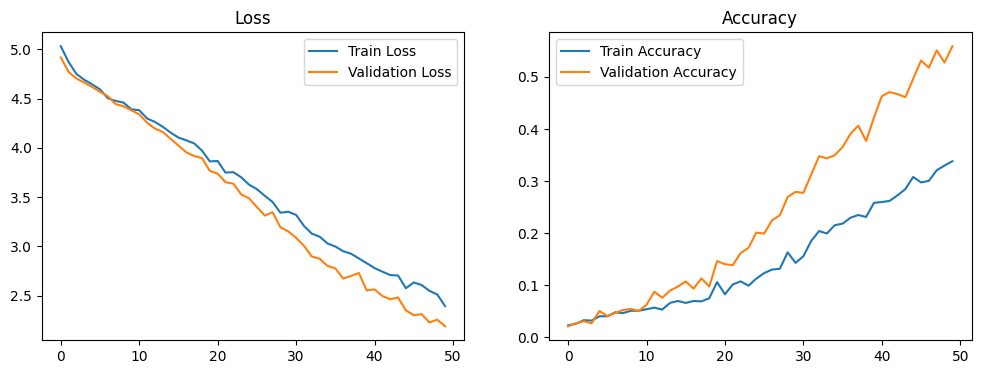

X_train: torch.Size([2044, 4, 3128])
X_test: torch.Size([512, 4, 3128])
y_train: torch.Size([2044])
y_test: torch.Size([512])
Epoch 1/50 - loss: 5.0286 - acc: 0.0120 - val_loss: 4.9054 - val_acc: 0.0215
Epoch 2/50 - loss: 4.8733 - acc: 0.0143 - val_loss: 4.7780 - val_acc: 0.0371
Epoch 3/50 - loss: 4.7570 - acc: 0.0248 - val_loss: 4.6860 - val_acc: 0.0332
Epoch 4/50 - loss: 4.6895 - acc: 0.0256 - val_loss: 4.6724 - val_acc: 0.0410
Epoch 5/50 - loss: 4.6305 - acc: 0.0294 - val_loss: 4.5657 - val_acc: 0.0430
Epoch 6/50 - loss: 4.5801 - acc: 0.0354 - val_loss: 4.5443 - val_acc: 0.0508
Epoch 7/50 - loss: 4.5332 - acc: 0.0354 - val_loss: 4.5000 - val_acc: 0.0508
Epoch 8/50 - loss: 4.4627 - acc: 0.0331 - val_loss: 4.4352 - val_acc: 0.0527
Epoch 9/50 - loss: 4.3993 - acc: 0.0414 - val_loss: 4.4010 - val_acc: 0.0508
Epoch 10/50 - loss: 4.3809 - acc: 0.0489 - val_loss: 4.3499 - val_acc: 0.0645
Epoch 11/50 - loss: 4.3452 - acc: 0.0527 - val_loss: 4.3355 - val_acc: 0.0684
Epoch 12/50 - loss: 4.322

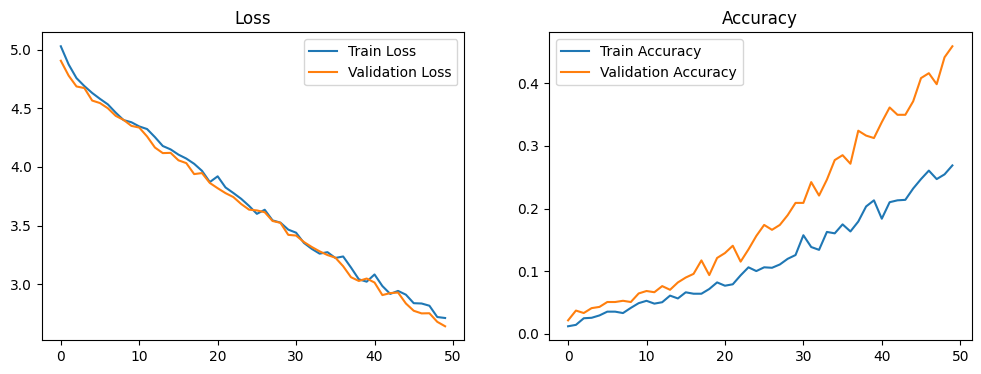

X_train: torch.Size([2044, 4, 3128])
X_test: torch.Size([512, 4, 3128])
y_train: torch.Size([2044])
y_test: torch.Size([512])
Epoch 1/50 - loss: 5.0334 - acc: 0.0113 - val_loss: 4.9283 - val_acc: 0.0176
Epoch 2/50 - loss: 4.8802 - acc: 0.0151 - val_loss: 4.8597 - val_acc: 0.0332
Epoch 3/50 - loss: 4.7850 - acc: 0.0256 - val_loss: 4.7429 - val_acc: 0.0332
Epoch 4/50 - loss: 4.7473 - acc: 0.0233 - val_loss: 4.6996 - val_acc: 0.0371
Epoch 5/50 - loss: 4.6813 - acc: 0.0233 - val_loss: 4.6509 - val_acc: 0.0352
Epoch 6/50 - loss: 4.6585 - acc: 0.0294 - val_loss: 4.5989 - val_acc: 0.0195
Epoch 7/50 - loss: 4.5674 - acc: 0.0354 - val_loss: 4.5037 - val_acc: 0.0566
Epoch 8/50 - loss: 4.5071 - acc: 0.0331 - val_loss: 4.4689 - val_acc: 0.0391
Epoch 9/50 - loss: 4.4751 - acc: 0.0377 - val_loss: 4.3898 - val_acc: 0.0410
Epoch 10/50 - loss: 4.4066 - acc: 0.0377 - val_loss: 4.3427 - val_acc: 0.0488
Epoch 11/50 - loss: 4.3790 - acc: 0.0489 - val_loss: 4.3095 - val_acc: 0.0527
Epoch 12/50 - loss: 4.308

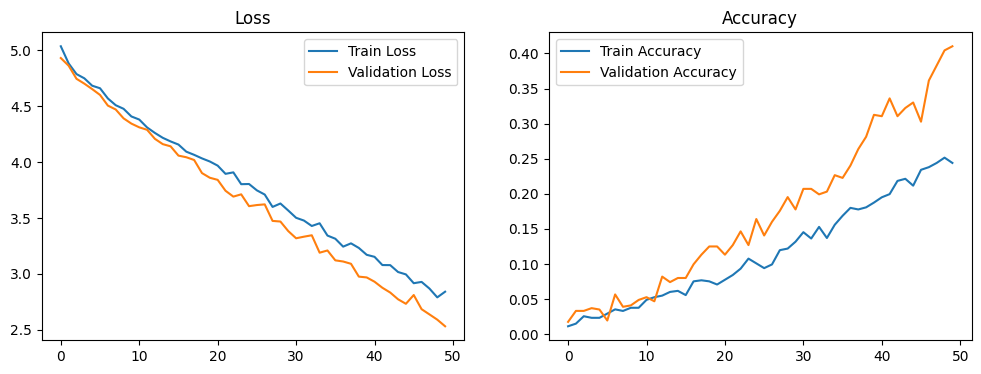

X_train: torch.Size([2044, 4, 3128])
X_test: torch.Size([512, 4, 3128])
y_train: torch.Size([2044])
y_test: torch.Size([512])
Epoch 1/50 - loss: 5.0446 - acc: 0.0098 - val_loss: 4.9208 - val_acc: 0.0234
Epoch 2/50 - loss: 4.8570 - acc: 0.0203 - val_loss: 4.7897 - val_acc: 0.0449
Epoch 3/50 - loss: 4.7694 - acc: 0.0233 - val_loss: 4.7430 - val_acc: 0.0488
Epoch 4/50 - loss: 4.7300 - acc: 0.0233 - val_loss: 4.7311 - val_acc: 0.0332
Epoch 5/50 - loss: 4.6664 - acc: 0.0482 - val_loss: 4.6735 - val_acc: 0.0410
Epoch 6/50 - loss: 4.6124 - acc: 0.0414 - val_loss: 4.6102 - val_acc: 0.0449
Epoch 7/50 - loss: 4.5391 - acc: 0.0452 - val_loss: 4.5737 - val_acc: 0.0410
Epoch 8/50 - loss: 4.5145 - acc: 0.0474 - val_loss: 4.5346 - val_acc: 0.0410
Epoch 9/50 - loss: 4.4251 - acc: 0.0474 - val_loss: 4.4822 - val_acc: 0.0547
Epoch 10/50 - loss: 4.3926 - acc: 0.0459 - val_loss: 4.4325 - val_acc: 0.0645
Epoch 11/50 - loss: 4.3578 - acc: 0.0557 - val_loss: 4.3872 - val_acc: 0.0508
Epoch 12/50 - loss: 4.320

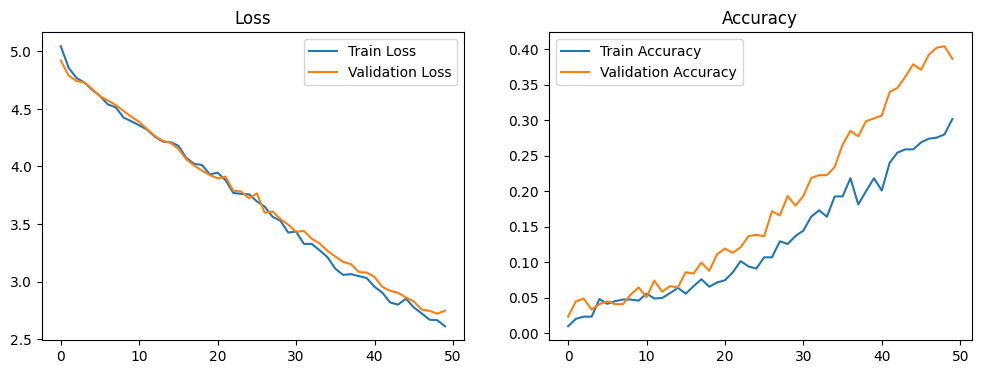

X_train: torch.Size([2044, 4, 3128])
X_test: torch.Size([512, 4, 3128])
y_train: torch.Size([2044])
y_test: torch.Size([512])
Epoch 1/50 - loss: 5.0578 - acc: 0.0075 - val_loss: 4.9358 - val_acc: 0.0117
Epoch 2/50 - loss: 4.8856 - acc: 0.0151 - val_loss: 4.7694 - val_acc: 0.0332
Epoch 3/50 - loss: 4.7813 - acc: 0.0264 - val_loss: 4.7180 - val_acc: 0.0332
Epoch 4/50 - loss: 4.7341 - acc: 0.0233 - val_loss: 4.6842 - val_acc: 0.0410
Epoch 5/50 - loss: 4.6893 - acc: 0.0294 - val_loss: 4.6440 - val_acc: 0.0410
Epoch 6/50 - loss: 4.6277 - acc: 0.0392 - val_loss: 4.5867 - val_acc: 0.0469
Epoch 7/50 - loss: 4.5540 - acc: 0.0324 - val_loss: 4.5126 - val_acc: 0.0469
Epoch 8/50 - loss: 4.5002 - acc: 0.0444 - val_loss: 4.4419 - val_acc: 0.0488
Epoch 9/50 - loss: 4.4414 - acc: 0.0452 - val_loss: 4.3264 - val_acc: 0.0508
Epoch 10/50 - loss: 4.3517 - acc: 0.0512 - val_loss: 4.2267 - val_acc: 0.0625
Epoch 11/50 - loss: 4.3132 - acc: 0.0505 - val_loss: 4.2245 - val_acc: 0.0664
Epoch 12/50 - loss: 4.227

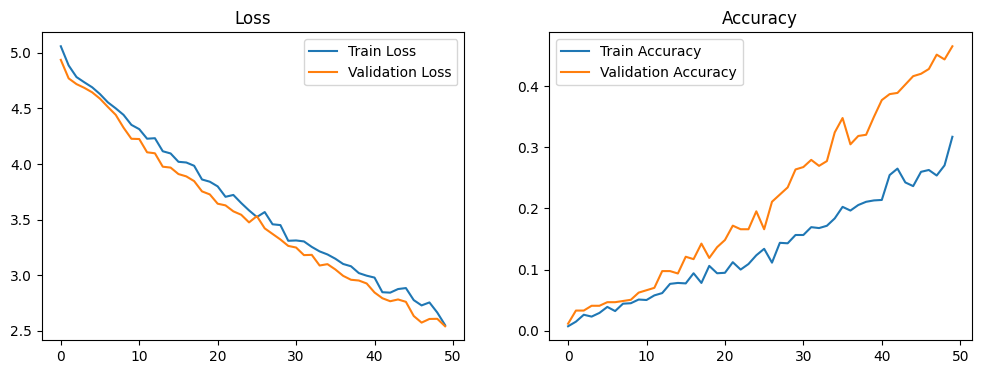

In [29]:
"""
Because you're using stratify, sklearn should preserve class proportions as much as possible,
but with classes containing only 2–3 examples, the available counts are inherently tiny.
"""

input_channels = X_train.shape[1]

n_estimators = 5
bagging_models = []

# we're keeping the naming for convention, but what it really is:
# y_train_categorical >>> y_train_numerical
# y_test_categorical >>> y_test_numerical
for i in range(n_estimators):

    X_bagging_train, _, y_bagging_train, _ = train_test_split(
        X_train,
        y_train_categorical,
        test_size=0.35,
        stratify=y_train_categorical,
        random_state=42 + i
    )

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_train:", y_train_categorical.shape)
    print("y_test:", y_test_categorical.shape)

    assert X_train.ndim == 3
    assert X_train.shape[1] == 4
    assert y_train_categorical.ndim == 1
    assert y_train_categorical.dtype == torch.long

    model, history = train_and_evaluate(
        X_bagging_train,
        y_bagging_train,
        X_test,
        y_test_categorical,
        input_channels,
        num_classes,
        max_length,
        learning_rate=0.001,
        dropout_rate=0.5,
        l2_reg=0.001,
        batch_size=16,
        epochs=50,
        patience=5
    )

    plot_training_history(history)
    bagging_models.append(model)

# save
os.makedirs('./models/bagged_cnn_models', exist_ok=True)

for i, model in enumerate(bagging_models):
    torch.save(model.state_dict(), f'./models/bagged_cnn_models/bagged_cnn_model_{i}.pth')

In [30]:
"""
Because your models return raw logits (correct for CrossEntropyLoss),
apply softmax before averaging the predictions.
"""

# Use the average prediction of the bagging models
y_preds = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # sanity check

for model in bagging_models:
    model.eval()
    model.to(device)

    with torch.no_grad():
        inputs = X_test.to(device)

        outputs = model(inputs)
        y_pred = torch.softmax(outputs, dim=1)

    y_preds.append(y_pred.cpu().numpy())

y_preds_mean = np.mean(y_preds, axis=0)
y_preds_mean_numerical = np.argmax(y_preds_mean, axis=1)

score = accuracy_score(y_test_numerical, y_preds_mean_numerical)
cm = confusion_matrix(y_test_numerical, y_preds_mean_numerical)
report = classification_report(
    y_test_numerical,
    y_preds_mean_numerical,
    zero_division=0
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           1       1.00      1.00      1.00         4
           2       1.00      0.25      0.40         4
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         4
           5       0.00      0.00      0.00         4
           6       0.50      1.00      0.67         1
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         1
          10       1.00      0.33      0.50         3
          11       1.00      1.00      1.00         1
          12       0.00      0.00      0.00         2
          13       0.90      1.00      0.95         9
          14       1.00      0.50      0.67         6
          16       0.00      0.00      0.00         2
          17       1.00      0.20      0.33         5
          18       1.00      1.00      1.00         5
   

In [31]:
unique_true = np.unique(y_test_numerical)
unique_pred = np.unique(y_preds_mean_numerical)

print("Classes in test set:     ", unique_true)
print("Classes predicted:      ", unique_pred)

missing_predictions = np.setdiff1d(unique_true, unique_pred)

print("Classes never predicted:", missing_predictions)

Classes in test set:      [  0   1   2   3   4   5   6   8   9  10  11  12  13  14  16  17  18  19
  20  21  22  23  25  26  27  28  29  30  31  33  34  36  37  38  39  41
  42  43  44  46  49  50  51  52  53  54  56  57  59  60  61  62  63  64
  65  66  67  68  69  71  72  73  75  76  77  78  79  80  81  82  84  85
  86  87  89  91  92  93  94  95  96  97  98  99 100 101 103 104 105 106
 108 110 112 113 115 116 117 118 119 120 122 123 124 125 126 127 129 130
 131 132 133 135 136 137 138 139 140 142 143 144 147 149 150 151 152 153
 154 155 156 157 159]
Classes predicted:       [  0   1   2   4   6   8   9  10  11  13  14  17  18  19  20  21  22  23
  25  26  27  29  30  31  33  34  36  37  38  39  40  41  42  43  44  46
  51  53  57  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  75  76  77  79  80  81  82  83  85  86  87  88  89  90  91  92  93  94
  96  97  98  99 100 101 103 104 106 108 112 113 115 117 118 119 120 125
 126 127 130 131 132 135 137 138 142 143 144 147 15

In [32]:
"""
So the warning isn't saying your model has poor overall performance.
It's saying that a handful of extremely rare classes aren't being recognized.
"""
test_counts = Counter(y_test_numerical)

for class_id in missing_predictions:
    print(f"Class {class_id}: {test_counts[class_id]} test samples")

print("-----------------------------------------------------------------------------")

train_counts = Counter(y_train_numerical)

for class_id in missing_predictions:
    print(f"Class {class_id}: {train_counts[class_id]} training samples")

Class 3: 1 test samples
Class 5: 4 test samples
Class 12: 2 test samples
Class 16: 2 test samples
Class 28: 1 test samples
Class 49: 1 test samples
Class 50: 2 test samples
Class 52: 1 test samples
Class 54: 1 test samples
Class 56: 2 test samples
Class 78: 2 test samples
Class 84: 2 test samples
Class 95: 1 test samples
Class 105: 3 test samples
Class 110: 1 test samples
Class 116: 1 test samples
Class 122: 3 test samples
Class 123: 2 test samples
Class 124: 2 test samples
Class 129: 1 test samples
Class 133: 1 test samples
Class 136: 2 test samples
Class 139: 1 test samples
Class 140: 2 test samples
Class 149: 3 test samples
Class 150: 1 test samples
Class 156: 6 test samples
-----------------------------------------------------------------------------
Class 3: 3 training samples
Class 5: 8 training samples
Class 12: 6 training samples
Class 16: 2 training samples
Class 28: 3 training samples
Class 49: 3 training samples
Class 50: 2 training samples
Class 52: 3 training samples
Class

### Meta Model

In [33]:
def get_bagged_model_predictions(models, X, batch_size=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = torch.utils.data.TensorDataset(
        torch.as_tensor(X, dtype=torch.float32)
    )

    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    all_model_predictions = []

    for model in models:
        model.to(device)
        model.eval()

        model_predictions = []

        with torch.no_grad():
            for (inputs,) in dataloader:
                inputs = inputs.to(device)

                outputs = model(inputs)
                probabilities = torch.softmax(outputs, dim=1)

                model_predictions.append(
                    probabilities.cpu()
                )

        model_predictions = torch.cat(
            model_predictions,
            dim=0
        )

        all_model_predictions.append(model_predictions)

        # Optional: move model back to CPU before loading
        # the next model onto the GPU.
        model.cpu()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # [num_models, num_samples, num_classes]
    all_model_predictions = torch.stack(
        all_model_predictions
    )

    # Average predictions across models
    # [num_samples, num_classes]
    y_preds_mean = all_model_predictions.mean(dim=0)

    return y_preds_mean

In [34]:
X_additional_train = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids_train
])

X_additional_test = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids_test
])

bagged_model_train_predictions = get_bagged_model_predictions(bagging_models, X_train)
bagged_model_test_predictions = get_bagged_model_predictions(bagging_models, X_test)

X_meta_train = np.hstack((X_additional_train, bagged_model_train_predictions))
X_meta_test = np.hstack((X_additional_test, bagged_model_test_predictions))

In [35]:
from sklearn.ensemble import RandomForestClassifier

meta_model = RandomForestClassifier(n_estimators=100, random_state=42)
meta_model.fit(X_meta_train, y_train_numerical)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_meta_pred_numerical = meta_model.predict(X_meta_test)
meta_score = accuracy_score(y_test_numerical, y_meta_pred_numerical)
meta_cm = confusion_matrix(y_test_numerical, y_meta_pred_numerical)
meta_report = classification_report(
    y_test_numerical,
    y_meta_pred_numerical,
    labels=np.arange(len(label_encoder.classes_)), # "Report all 160 possible classes, including ones that have zero test samples."
    target_names=label_encoder.classes_,
    zero_division=0
)

print("Meta-model Classification Report:\n", meta_report)
print("Meta-model Confusion Matrix:\n", meta_cm)
print(f"Meta-model Accuracy: {meta_score}")

Meta-model Classification Report:
                                                                            precision    recall  f1-score   support

                              100049 Himeringo - Yotsuya-san ni Yoroshiku       1.00      1.00      1.00         8
                                    1000972 Yorushika - Hole In The Heart       1.00      1.00      1.00         4
                                           1028168 ATSUMI UEDA - Harmonia       1.00      1.00      1.00         4
                                     1091022 Minase Inori - brave climber       1.00      1.00      1.00         1
                                                 1093583 Spire - sayonara       1.00      1.00      1.00         4
                                                     1096056 ASCA - CHAIN       0.00      0.00      0.00         4
                          1124086 Yorushika - Hachigatsu, Bou, Tsukiakari       1.00      1.00      1.00         1
                             1126559 Yuyoyup

In [37]:
print("Classes in full dataset:", len(label_encoder.classes_))
print("Classes in test set:", len(np.unique(y_test_numerical)))
print("Classes predicted:", len(np.unique(y_meta_pred_numerical)))

Classes in full dataset: 160
Classes in test set: 131
Classes predicted: 130


### Pruning


#### Training

In [38]:
def prune_models(
    models,
    initial_sparsity=0.30,
    final_sparsity=0.50, # adjust this based on dataset size, originally 0.70
    fine_tune_epochs=2,
    gradual=True,
    batch_size=16,
    learning_rate=0.0001
):
    pruned_models = []

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    for model_idx, model in enumerate(models):
        print(f"\nPruning model {model_idx + 1}/{len(models)}")

        # Preserve the original model
        pruned_model = copy.deepcopy(model)
        pruned_model.to(device)

        # Layers that will be pruned
        prunable_layers = [
            module
            for module in pruned_model.modules()
            if isinstance(module, (torch.nn.Conv1d, torch.nn.Linear))
        ]

        if gradual:
            # Reproduce:
            # initial_sparsity = 30%
            # final_sparsity   = 70%
            #
            # We prune progressively over the fine-tuning epochs.
            sparsities = torch.linspace(
                initial_sparsity,
                final_sparsity,
                fine_tune_epochs
            ).tolist()

        else:
            # Immediate pruning directly to final sparsity
            sparsities = [final_sparsity]

        # Fine-tuning dataset
        dataset = torch.utils.data.TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(y_train_numerical, dtype=torch.long)
        )

        dataloader = torch.utils.data.DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=True
        )

        criterion = torch.nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam(
            pruned_model.parameters(),
            lr=learning_rate
        )

        # ---------------------------------------------------------
        # Pruning / fine-tuning
        # ---------------------------------------------------------

        for epoch, target_sparsity in enumerate(sparsities):

            print(
                f"  Epoch {epoch + 1}/{len(sparsities)} "
                f"- target sparsity: {target_sparsity:.0%}"
            )

            for module in prunable_layers:

                if not hasattr(module, "weight_mask"):
                    # First pruning step
                    prune.l1_unstructured(
                        module,
                        name="weight",
                        amount=target_sparsity
                    )

                else:
                    # Increase sparsity while preserving
                    # the existing pruning mask
                    prune.l1_unstructured(
                        module,
                        name="weight",
                        amount=target_sparsity
                    )

            # Fine-tune after this pruning step
            pruned_model.train()

            running_loss = 0.0

            for inputs, targets in dataloader:

                inputs = inputs.to(device)
                targets = targets.to(device)

                optimizer.zero_grad()

                outputs = pruned_model(inputs)
                loss = criterion(outputs, targets)

                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            average_loss = running_loss / len(dataloader)

            print(
                f"    Fine-tune loss: {average_loss:.4f}"
            )

        # ---------------------------------------------------------
        # Make pruning permanent
        # ---------------------------------------------------------

        for module in prunable_layers:
            if hasattr(module, "weight_mask"):
                prune.remove(module, "weight")

        pruned_model.eval()
        pruned_models.append(pruned_model)

    return pruned_models

pruned_models = prune_models(bagging_models)

os.makedirs('./models/pruned_models', exist_ok=True)

for i, model in enumerate(bagging_models):
    torch.save(model.state_dict(), f'./models/pruned_models/pruned_model_{i}.pth')


Pruning model 1/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 2.7386
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 3.5242

Pruning model 2/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 3.0178
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 3.5032

Pruning model 3/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 2.9862
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 3.5444

Pruning model 4/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 2.9045
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 3.6475

Pruning model 5/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 2.9775
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 3.6113


### Testing

In [39]:
# ---------------------------------------------------------
# Load bagged CNN models
# ---------------------------------------------------------

start = time.perf_counter()

model_folder = "./models/bagged_cnn_models/"

model_kwargs = {
    "input_channels": 4,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5
}

bagged_models = load_pytorch_models(
    model_folder,
    CNN_Model,
    model_kwargs
)

end = time.perf_counter()

print(
    f"Loaded {len(bagged_models)} bagged models "
    f"in {end - start:.4f} seconds"
)


# ---------------------------------------------------------
# Load pruned CNN models
# ---------------------------------------------------------

start = time.perf_counter()

model_folder = "./models/pruned_models/"

stripped_pruned = load_pytorch_models(
    model_folder,
    CNN_Model,
    model_kwargs
)

end = time.perf_counter()

print(
    f"Loaded {len(stripped_pruned)} pruned models "
    f"in {end - start:.4f} seconds"
)

Loaded 5 bagged models in 0.0899 seconds
Loaded 5 pruned models in 0.0777 seconds


In [40]:
# ---------------------------------------------------------
# Prepare test data
# ---------------------------------------------------------

target_names = label_encoder.classes_
labels = np.arange(len(label_encoder.classes_))

In [41]:
# ---------------------------------------------------------
# Bagged CNN models
# ---------------------------------------------------------

start = time.perf_counter()

y_preds_mean = get_bagged_model_predictions(
    bagged_models,
    X_test,
    batch_size=16
)

end = time.perf_counter()

print(f"Bagged prediction time: {end - start:.4f} seconds")

y_preds_mean_numerical = y_preds_mean.argmax(dim=1).numpy()


score = accuracy_score(
    y_test_numerical,
    y_preds_mean_numerical
)

cm = confusion_matrix(
    y_test_numerical,
    y_preds_mean_numerical,
    labels=labels
)

report = classification_report(
    y_test_numerical,
    y_preds_mean_numerical,
    labels=labels,
    target_names=target_names,
    zero_division=0
)

print("\n========== BAGGED CNN MODELS ==========")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score:.4f}")

Bagged prediction time: 0.1470 seconds

========== BAGGED CNN MODELS ==========
Classification Report:
                                                                            precision    recall  f1-score   support

                              100049 Himeringo - Yotsuya-san ni Yoroshiku       0.64      0.88      0.74         8
                                    1000972 Yorushika - Hole In The Heart       1.00      1.00      1.00         4
                                           1028168 ATSUMI UEDA - Harmonia       1.00      0.25      0.40         4
                                     1091022 Minase Inori - brave climber       0.00      0.00      0.00         1
                                                 1093583 Spire - sayonara       1.00      1.00      1.00         4
                                                     1096056 ASCA - CHAIN       0.00      0.00      0.00         4
                          1124086 Yorushika - Hachigatsu, Bou, Tsukiakari       0.50      

In [42]:
# ---------------------------------------------------------
# Pruned CNN models
# ---------------------------------------------------------

start = time.perf_counter()

y_pruned_preds_mean = get_bagged_model_predictions(
    pruned_models,
    X_test,
    batch_size=16
)

end = time.perf_counter()

print(f"Pruned prediction time: {end - start:.4f} seconds")

y_pruned_preds_mean_numerical = (
    y_pruned_preds_mean.argmax(dim=1).numpy()
)


score_pruned = accuracy_score(
    y_test_numerical,
    y_pruned_preds_mean_numerical
)

cm_pruned = confusion_matrix(
    y_test_numerical,
    y_pruned_preds_mean_numerical,
    labels=labels
)

report_pruned = classification_report(
    y_test_numerical,
    y_pruned_preds_mean_numerical,
    labels=labels,
    target_names=target_names,
    zero_division=0
)

print("\n========== PRUNED CNN MODELS ==========")
print("Classification Report:\n", report_pruned)
print("Confusion Matrix:\n", cm_pruned)
print(f"Accuracy: {score_pruned:.4f}")

Pruned prediction time: 0.1886 seconds

========== PRUNED CNN MODELS ==========
Classification Report:
                                                                            precision    recall  f1-score   support

                              100049 Himeringo - Yotsuya-san ni Yoroshiku       0.78      0.88      0.82         8
                                    1000972 Yorushika - Hole In The Heart       1.00      0.50      0.67         4
                                           1028168 ATSUMI UEDA - Harmonia       0.00      0.00      0.00         4
                                     1091022 Minase Inori - brave climber       0.00      0.00      0.00         1
                                                 1093583 Spire - sayonara       1.00      1.00      1.00         4
                                                     1096056 ASCA - CHAIN       0.00      0.00      0.00         4
                          1124086 Yorushika - Hachigatsu, Bou, Tsukiakari       1.00      